# MRI Brain Tumor Dataset: 4-Class From Kaggle
Learn about medical AI

#### Import

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt

#### Load Dataset

In [2]:
TRAIN_DIR = "Training"

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_full = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_full = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=val_transform
)

class_names = train_full.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total training folder images:", len(train_full))

Classes: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']
Number of classes: 4
Total training folder images: 5712


In [3]:
val_size = int(len(train_full) * 0.15)
train_size = len(train_full) - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(train_full), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Train images: 4856
Validation images: 856


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

#### Visualization of Dataset

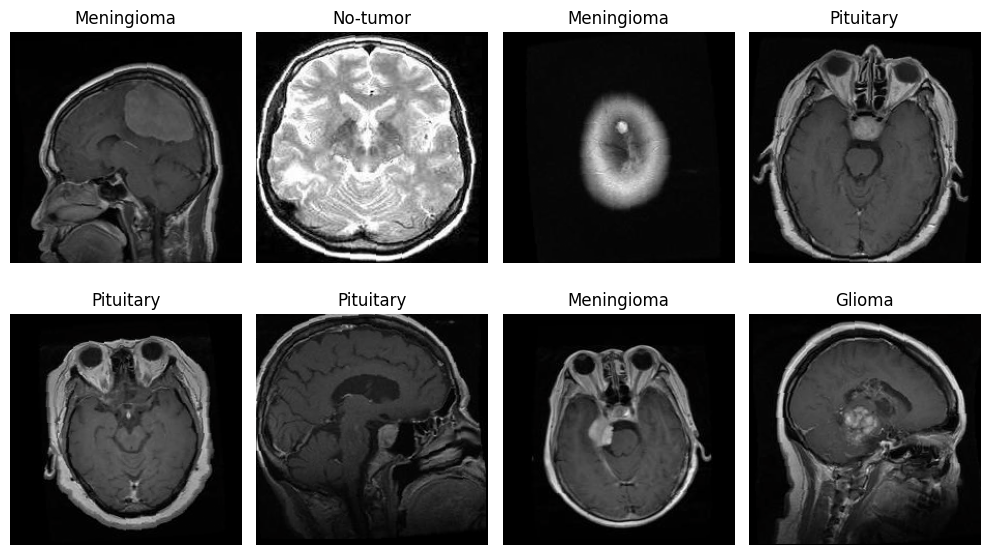

In [6]:
# Visa några bilder från batchen
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    img = images[i].permute(1, 2, 0)

    # undo Normalize ungefärligt för visualisering
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std + mean
    img = img.clamp(0, 1)

    label = labels[i].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### DenseLayer
Regular CNN: 64 Channel --> 16 Channel

Dense: 64ch + 16ch --> 80ch, meaning it keeps all the old features aswell.


In [ ]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, gain):
        super().__init__()

        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True), # Save memory with inplace
            nn.Conv2d(in_channels, 4*gain, kernel_size=1, bias=False), # -------------------------------
            
            nn.BatchNorm2d(4*gain),
            nn.ReLU(inplace=True),
            nn.Conv2d(4*gain, gain, kernel_size=3, padding=1, bias=False)
        )
    
    def forward(self, x):
        new_features = self.layer(x)
        return torch.cat([x, new_features], dim=1)

### Transition Layer?

In [ ]:
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, compression=0.5):
        super().__init__()

        out_channels = int(in_channels * compression)

        self.transition = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),

            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.out.channels = out_channels

    def forward(self, x):
        return self.transition(x)

## DenseBlock

### Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Testing